# Testing Notebook 
This notebook is to test our class and functions 

## Testing class functionality

In [1]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random, importlib
import matplotlib.pyplot as plt

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode

# import our functions 
os.chdir("../preprocessing")
import tumor_dataset

importlib.reload(tumor_dataset)
from tumor_dataset import Dataset

below is code to test our loading and cashing functionalities, not neccarily our functions themselves

In [2]:
d = Dataset(data_path="../../data/raw_data/useable_data")
# d.preprocess_images()
# d.split_train_val_test(80, 10, 10)
# d.cashe_data()

Data loaded from cache.


Text(0.5, 1.0, 'mask')

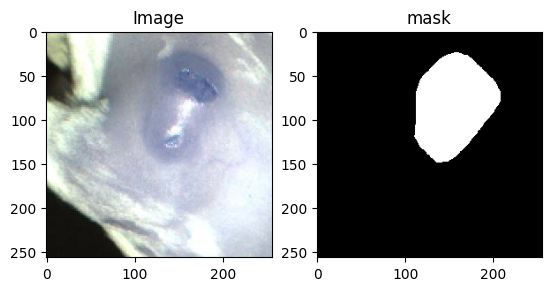

In [3]:
train_images, train_masks, val_images, val_masks, test_images, test_masks = d.load_data()
f, ax = plt.subplots(1,2)
num = random.randint(0, len(train_images))
ax[0].imshow(train_images[num])
ax[0].set_title("Image")
ax[1].imshow(train_masks[num], cmap="gray")
ax[1].set_title("mask")

now we are going to convert the binary image to coco json 

In [3]:
from detectron2.data.datasets import register_coco_instances
d.convert_binary_to_coco()

register_coco_instances("my_dataset_train", {}, "../../data/processed_data/train/images/train.json", "../../data/processed_data/train/images/")
register_coco_instances("my_dataset_val", {}, "../../data/processed_data/val/images/val.json", "../../data/processed_data/val/images/")
register_coco_instances("my_dataset_test", {}, "../../data/processed_data/test/images/test.json", "../../data/processed_data/test/images/")

Created 613 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/train/masks
Created 259 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/val/masks
Created 28 annotations for images in folder: /Users/abirmodak/Documents/tumor/data/processed_data/test/masks


In [4]:
train_metadata = MetadataCatalog.get("my_dataset_train")
train_dataset_dicts = DatasetCatalog.get("my_dataset_train")

val_metadata = MetadataCatalog.get("my_dataset_val")
val_dataset_dicts = DatasetCatalog.get("my_dataset_val")

test_metadata = MetadataCatalog.get("my_dataset_test")
test_dataset_dicts = DatasetCatalog.get("my_dataset_test")

[07/01 05:14:51 d2.data.datasets.coco]: Loaded 220 images in COCO format from ../../data/processed_data/train/images/train.json
[07/01 05:14:52 d2.data.datasets.coco]: Loaded 27 images in COCO format from ../../data/processed_data/val/images/val.json
[07/01 05:14:52 d2.data.datasets.coco]: Loaded 28 images in COCO format from ../../data/processed_data/test/images/test.json


test annotations at a glance

Image file: ../../data/processed_data/val/images/val_4.jpg
Mask file: ../../data/processed_data/val/masks/Tumor/val_4.png


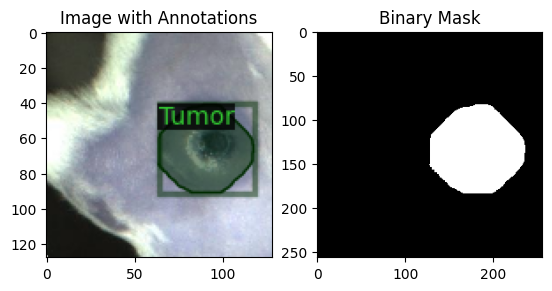

In [38]:
mask_folder = "../../data/processed_data/val/masks/Tumor"  # Update with your binary mask folder path

for d in random.sample(val_dataset_dicts, 1):
    # Load the image
    img = cv2.imread(d["file_name"])

    print(f"Image file: {d['file_name']}")
    
    # Check if the image was successfully loaded
    if img is None:
        print(f"Failed to load image: {d['file_name']}")
        continue

    # Visualize the image with annotations
    visualizer = Visualizer(img[:, :, ::-1], metadata=val_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)

    # Display the annotated image
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
    plt.imshow(vis.get_image()[:, :, ::-1])
    plt.title("Image with Annotations")

    # Load the corresponding binary mask
    image_base_name = os.path.basename(d["file_name"]).split(".")[0]  # Get base name of the image
    mask_path = os.path.join(mask_folder, f"{image_base_name}.png")  # Assuming masks have .jpg extension

    print(f"Mask file: {mask_path}")
    
    # Load the binary mask
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Check if the mask was successfully loaded
    if mask_img is None:
        print(f"Failed to load mask: {mask_path}")
        continue

    # Display the binary mask
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
    plt.imshow(mask_img, cmap="gray")
    plt.title("Binary Mask")

    plt.show()  # Display the images side by side